In [1]:
# Import Libraries
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
from matplotlib import rcParams
import time
from datetime import datetime

# PyTorch and PyTorch Geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv, global_mean_pool, BatchNorm
from torch_geometric.data import Data, DataLoader
from torch_geometric.utils import dense_to_sparse

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# SHAP for interpretability
import shap

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"2D Graph Transformer started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


PyTorch version: 2.5.1+cpu
2D Graph Transformer started at: 2026-02-24 10:14:26


# HELPER FUNCTIONS

In [2]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    """Convert time series data to supervised learning format."""
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    
    # Input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    
    # Forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [3]:
def create_2d_spatial_graph(n_stations=2, n_features=13, k_neighbors=5):
    """Create advanced 2D spatial graph for multi-station modeling."""
    total_nodes = n_stations * n_features
    
    # Initialize adjacency matrix
    adj_matrix = np.zeros((total_nodes, total_nodes))
    
    # 1. Intra-station connections: Connect features within same station
    for station in range(n_stations):
        start_idx = station * n_features
        end_idx = (station + 1) * n_features
        
        # Create fully connected subgraph for each station
        for i in range(start_idx, end_idx):
            for j in range(start_idx, end_idx):
                if i != j:
                    # Weight connections based on typical air quality correlations
                    weight = np.random.uniform(0.5, 1.0)  # Strong intra-station connections
                    adj_matrix[i, j] = weight
    
    # 2. Inter-station connections: Connect same features across stations
    for feature in range(n_features):
        for station1 in range(n_stations):
            for station2 in range(station1 + 1, n_stations):
                idx1 = station1 * n_features + feature
                idx2 = station2 * n_features + feature
                # Same feature across stations should have strong connection
                weight = np.random.uniform(0.7, 1.0)  # Strong inter-station connections
                adj_matrix[idx1, idx2] = weight
                adj_matrix[idx2, idx1] = weight
    
    # 3. Cross-feature inter-station connections (weaker)
    for station1 in range(n_stations):
        for station2 in range(station1 + 1, n_stations):
            start1, end1 = station1 * n_features, (station1 + 1) * n_features
            start2, end2 = station2 * n_features, (station2 + 1) * n_features
            
            # Add some cross-feature connections between stations
            for i in range(start1, end1):
                for j in range(start2, end2):
                    if np.random.random() < 0.3:  # 30% chance of connection
                        weight = np.random.uniform(0.2, 0.5)  # Weaker connections
                        adj_matrix[i, j] = weight
                        adj_matrix[j, i] = weight
    
    # Add self-connections
    np.fill_diagonal(adj_matrix, 1.0)
    
    # Convert to edge list
    edge_index, edge_weights = dense_to_sparse(torch.tensor(adj_matrix, dtype=torch.float))
    
    return edge_index, edge_weights

In [4]:
def create_positional_encoding_2d(n_stations, n_features, d_model):
    """Create 2D positional encoding for multi-station data."""
    total_nodes = n_stations * n_features
    pe = torch.zeros(total_nodes, d_model)
    
    for station in range(n_stations):
        for feature in range(n_features):
            node_id = station * n_features + feature
            position = node_id
            
            div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                               -(np.log(10000.0) / d_model))
            
            pe[node_id, 0::2] = torch.sin(position * div_term)
            if d_model % 2 == 1:
                pe[node_id, 1::2] = torch.cos(position * div_term[:-1])
            else:
                pe[node_id, 1::2] = torch.cos(position * div_term)
    
    return pe

In [5]:
def create_2d_graph_sequence_data(X, Y, n_stations=2, n_features=13):
    """Convert 2D multi-station sequence data to graph format."""
    graph_data_list = []
    
    # Create base graph structure for 2D spatial connections
    edge_index, edge_attr = create_2d_spatial_graph(n_stations, n_features)
    total_nodes = n_stations * n_features
    
    for i in range(len(X)):
        # Reshape X from flat to 2D: [stations, features] 
        x_2d = X[i].reshape(n_stations, n_features)
        
        # Create node features: [total_nodes, 1] (each node has one feature value)
        node_features = torch.tensor(x_2d.flatten().reshape(-1, 1), dtype=torch.float32)
        
        # Create graph data object
        data = Data(
            x=node_features,
            edge_index=edge_index.long(),
            edge_attr=edge_attr.float(),
            y=torch.tensor([Y[i]], dtype=torch.float32),
            n_stations=torch.tensor([n_stations], dtype=torch.long),
            n_features=torch.tensor([n_features], dtype=torch.long)
        )
        graph_data_list.append(data)
    
    return graph_data_list


# LOAD MULTI-STATION DATASET

In [6]:
print("Loading multi-station dataset...")

# Load and merge two stations 
stations = ['Secunda', 'Ermelo']
dfs = []

for st in stations:
    try:
        df = pd.read_csv(f'C:\\Users\\User\\Documents\\GitHub\\Health-impacts-of-air-pollution\\AirData\\{st}IM.csv', sep=';', header=0, index_col=0)
        # Rename columns to keep track of station
        df.columns = [f'{st}_{c}' for c in df.columns]
        dfs.append(df)
        print(f"Loaded {st} station: {df.shape}")
    except FileNotFoundError:
        print(f"Warning: Could not load {st}IM.csv - file not found")

if len(dfs) == 2:
    # Merge datasets
    data = pd.concat(dfs, axis=1).dropna()
    values = data.values
    print(f"Merged dataset shape: {data.shape}")
    print(f"Columns: {list(data.columns)}")
    
    # Store feature names for later use (extract only unique features, not per-station duplicates)
    # All stations have the same features, so we extract from the first station only
    unique_feature_names = [col.replace(f'{stations[0]}_', '') for col in data.columns if col.startswith(stations[0])]
else:
    print("Error: Could not load both station files")
    exit(1)

n_stations = len(stations)
n_vars = values.shape[1]
n_feats = int(n_vars / n_stations)

print(f"Number of stations: {n_stations}")
print(f"Features per station: {n_feats}")
print(f"Total variables: {n_vars}")

Loading multi-station dataset...
Loaded Secunda station: (87647, 13)
Loaded Ermelo station: (87647, 13)
Merged dataset shape: (87647, 26)
Columns: ['Secunda_pm2.5', 'Secunda_pm10', 'Secunda_so2', 'Secunda_no2', 'Secunda_no', 'Secunda_nox', 'Secunda_o3', 'Secunda_co', 'Secunda_ws', 'Secunda_wd', 'Secunda_temp', 'Secunda_relHum', 'Secunda_pressure', 'Ermelo_pm2.5', 'Ermelo_pm10', 'Ermelo_so2', 'Ermelo_no2', 'Ermelo_no', 'Ermelo_nox', 'Ermelo_o3', 'Ermelo_co', 'Ermelo_ws', 'Ermelo_wd', 'Ermelo_temp', 'Ermelo_relHum', 'Ermelo_pressure']
Number of stations: 2
Features per station: 13
Total variables: 26


# DATA PREPROCESSING

In [7]:
print("Preprocessing data...")

# Ensure all data is float
values = values.astype('float32')

# Normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

# Frame as supervised learning
reframed = series_to_supervised(scaled, 1, 1)

# Drop columns we don't want to predict (keep only first station's PM2.5)
drop = list(range(n_vars+1, 2*n_vars))
reframed.drop(reframed.columns[drop], axis=1, inplace=True)
values = reframed.values

print(f"Supervised data shape: {values.shape}")

# Split into input and output
X = values[:,:-1]  # All columns except last
Y = values[:,-1]   # Last column (PM2.5 prediction target)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

# Convert to graph sequence data format
graph_data = create_2d_graph_sequence_data(X, Y, n_stations, n_feats)
print(f"Created {len(graph_data)} 2D graph sequence samples")

Preprocessing data...
Supervised data shape: (87646, 27)
X shape: (87646, 26)
Y shape: (87646,)
Created 87646 2D graph sequence samples


In [8]:
# DATA SPLITTING

In [9]:
print("Splitting data...")

# Split data: 60% train, 20% validation, 20% test
n_samples = len(graph_data)
indices = list(range(n_samples))

train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=42)

train_data = [graph_data[i] for i in train_idx]
val_data = [graph_data[i] for i in val_idx]
test_data = [graph_data[i] for i in test_idx]

print(f"Train: {len(train_data)} samples")
print(f"Val: {len(val_data)} samples")
print(f"Test: {len(test_data)} samples")

Splitting data...
Train: 52587 samples
Val: 17529 samples
Test: 17530 samples


# 2D GRAPH TRANSFORMER MODEL COMPONENTS

In [10]:
class MultiHeadGraphAttention2D(nn.Module):
    """2D Multi-head graph attention for multi-station spatial modeling."""
    
    def __init__(self, in_dim, out_dim, num_heads=8, dropout=0.1):
        super(MultiHeadGraphAttention2D, self).__init__()
        self.num_heads = num_heads
        self.out_dim = out_dim
        self.head_dim = out_dim // num_heads
        
        assert self.head_dim * num_heads == out_dim
        
        self.transformers = nn.ModuleList([
            TransformerConv(in_dim, self.head_dim, heads=1, dropout=dropout)
            for _ in range(num_heads)
        ])
        
        self.output_projection = nn.Linear(out_dim, out_dim)
        self.layer_norm = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, edge_index, edge_attr=None):
        # Multi-head attention (ignore edge_attr to avoid dimension mismatch)
        head_outputs = []
        for transformer in self.transformers:
            head_out = transformer(x, edge_index)  # Remove edge_attr parameter
            head_outputs.append(head_out)
        
        # Concatenate heads
        multi_head_out = torch.cat(head_outputs, dim=-1)
        
        # Output projection and residual connection
        out = self.output_projection(multi_head_out)
        out = self.layer_norm(out + x if x.size(-1) == self.out_dim else out)
        out = self.dropout(out)
        
        return out

In [11]:
class SpatialTemporalLayer(nn.Module):
    """Spatial-temporal modeling layer for 2D data."""
    
    def __init__(self, d_model, num_heads=8, d_ff=256, dropout=0.1, n_stations=2, n_features=13):
        super(SpatialTemporalLayer, self).__init__()
        
        self.n_stations = n_stations
        self.n_features = n_features
        self.d_model = d_model
        
        # Station-wise attention
        self.station_attention = nn.MultiheadAttention(
            d_model, num_heads, dropout=dropout, batch_first=True
        )
        
        # Feature-wise attention
        self.feature_attention = nn.MultiheadAttention(
            d_model, num_heads, dropout=dropout, batch_first=True
        )
        
        # Feed-forward networks
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.layer_norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        batch_size = x.size(0)
        
        # Reshape to separate stations and features: [batch, stations, features, d_model]
        x_reshaped = x.view(batch_size, self.n_stations, self.n_features, self.d_model)
        
        # Station-wise attention (aggregate across stations for each feature)
        station_out = []
        for feature in range(self.n_features):
            feat_data = x_reshaped[:, :, feature, :]  # [batch, stations, d_model]
            attn_out, _ = self.station_attention(feat_data, feat_data, feat_data)
            station_out.append(attn_out)
        
        station_out = torch.stack(station_out, dim=2)  # [batch, stations, features, d_model]
        x = x + self.dropout(station_out.view(batch_size, -1, self.d_model))
        x = self.layer_norm1(x)
        
        # Feature-wise attention (aggregate across features for each station)
        x_reshaped = x.view(batch_size, self.n_stations, self.n_features, self.d_model)
        feature_out = []
        for station in range(self.n_stations):
            stat_data = x_reshaped[:, station, :, :]  # [batch, features, d_model]
            attn_out, _ = self.feature_attention(stat_data, stat_data, stat_data)
            feature_out.append(attn_out)
        
        feature_out = torch.stack(feature_out, dim=1)  # [batch, stations, features, d_model]
        x = x + self.dropout(feature_out.view(batch_size, -1, self.d_model))
        x = self.layer_norm2(x)
        
        # Feed-forward
        ff_out = self.feed_forward(x)
        x = x + self.dropout(ff_out)
        x = self.layer_norm3(x)
        
        return x

In [12]:
class GraphTransformer2DModel(nn.Module):
    """2D Graph Transformer Network for multi-station air pollution prediction."""
    
    def __init__(self, input_dim=1, d_model=128, num_graph_layers=2, 
                 num_spatial_layers=2, num_heads=8, dropout=0.1,
                 n_stations=2, n_features=13):
        super(GraphTransformer2DModel, self).__init__()
        
        self.n_stations = n_stations
        self.n_features = n_features
        self.d_model = d_model
        self.total_nodes = n_stations * n_features
        
        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # 2D Positional encoding
        self.register_buffer('pos_encoding', 
                           create_positional_encoding_2d(n_stations, n_features, d_model))
        
        # Spatial graph attention layers
        self.graph_layers = nn.ModuleList([
            MultiHeadGraphAttention2D(d_model, d_model, num_heads, dropout)
            for _ in range(num_graph_layers)
        ])
        
        # Spatial-temporal layers for 2D modeling
        self.spatial_temporal_layers = nn.ModuleList([
            SpatialTemporalLayer(d_model, num_heads, d_model*2, dropout, n_stations, n_features)
            for _ in range(num_spatial_layers)
        ])
        
        # Multi-station aggregation
        self.station_aggregation = nn.Sequential(
            nn.Linear(d_model * self.total_nodes, d_model * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Final prediction head
        self.prediction_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 4, 1),
            nn.Sigmoid()
        )
    
    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        
        # Input projection: [nodes, input_dim] -> [nodes, d_model]
        x = self.input_projection(x)
        
        # Add positional encoding (cycle through positions for batch processing)
        batch_size = batch.max().item() + 1
        nodes_per_graph = x.size(0) // batch_size
        pos_enc = self.pos_encoding[:nodes_per_graph].repeat(batch_size, 1)
        x = x + pos_enc
        
        # Spatial modeling with graph attention
        for graph_layer in self.graph_layers:
            x = graph_layer(x, edge_index, edge_attr)
        
        # Reshape for spatial-temporal modeling: [batch_size, total_nodes, d_model]
        x_spatial = x.view(batch_size, self.total_nodes, self.d_model)
        
        # Spatial-temporal modeling for 2D structure
        for spatial_layer in self.spatial_temporal_layers:
            x_spatial = spatial_layer(x_spatial)
        
        # Multi-station aggregation: flatten and aggregate all node features
        x_flat = x_spatial.view(batch_size, -1)
        x_aggregated = self.station_aggregation(x_flat)
        
        # Final prediction
        out = self.prediction_head(x_aggregated)
        
        return out.squeeze()

# MODEL TRAINING SETUP

In [13]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create data loaders
batch_size = 64  # Smaller batch size due to model complexity
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Initialize model
model = GraphTransformer2DModel(
    input_dim=1,
    d_model=128,
    num_graph_layers=2,
    num_spatial_layers=2,
    num_heads=8,
    dropout=0.1,
    n_stations=n_stations,
    n_features=n_feats
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

Using device: cpu
Model parameters: 2,442,497


# TRAINING FUNCTIONS

In [14]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)
        loss = criterion(out, batch.y)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

In [15]:
def evaluate_model(model, data_loader, criterion, device):
    """Evaluate the model."""
    model.eval()
    total_loss = 0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out, batch.y)
            
            total_loss += loss.item()
            predictions.extend(out.cpu().numpy())
            targets.extend(batch.y.cpu().numpy())
    
    return total_loss / len(data_loader), np.array(predictions), np.array(targets)

# MODEL TRAINING

In [16]:
print("Starting 2D Graph Transformer training...")

# Training parameters
epochs = 80
best_val_loss = float('inf')
patience = 12
patience_counter = 0

# Training history
train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(epochs):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)
    
    # Validate
    val_loss, _, _ = evaluate_model(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step()
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), '2d_graph_transformer_best_model.pth')
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

# Load best model for evaluation
model.load_state_dict(torch.load('2d_graph_transformer_best_model.pth'))

Starting 2D Graph Transformer training...
Epoch [10/80] - Train Loss: 0.001307, Val Loss: 0.001254
Epoch [20/80] - Train Loss: 0.001122, Val Loss: 0.001006
Epoch [30/80] - Train Loss: 0.000946, Val Loss: 0.000995
Early stopping at epoch 38
Training completed in 27094.40 seconds


<All keys matched successfully>

# MODEL EVALUATION

In [17]:
print("Evaluating 2D Graph Transformer model...")

# Test evaluation
test_loss, test_predictions, test_targets = evaluate_model(model, test_loader, criterion, device)

# Unscale predictions for evaluation
def unscale(scaled_value):
    """Unscale normalized values back to original scale."""
    return scaled_value * (scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]

predictions_unscaled = unscale(test_predictions)
targets_unscaled = unscale(test_targets)

# Calculate metrics
mse = mean_squared_error(targets_unscaled, predictions_unscaled)
rmse = sqrt(mse)
mae = mean_absolute_error(targets_unscaled, predictions_unscaled)
r2 = r2_score(targets_unscaled, predictions_unscaled)

print(f"\n2D Graph Transformer Model Performance:")
print(f"Test MSE: {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE: {mae:.6f}")
print(f"Test R²: {r2:.6f}")

Evaluating 2D Graph Transformer model...

2D Graph Transformer Model Performance:
Test MSE: 670.760986
Test RMSE: 25.899054
Test MAE: 9.462320
Test R²: 0.724919


# VISUALIZATIONS

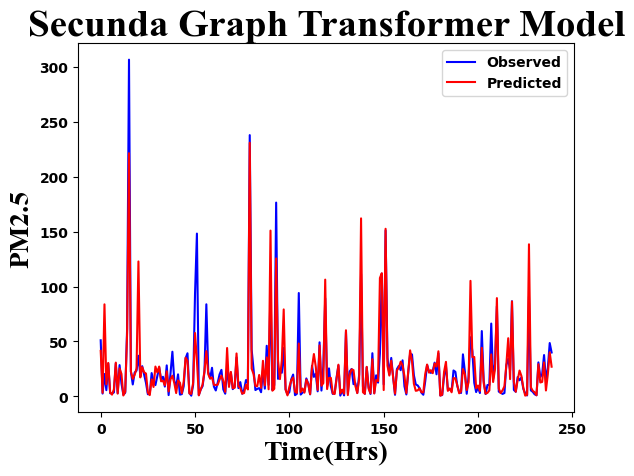

In [18]:
rcParams['font.weight'] = 'bold'
plt.plot(targets_unscaled[0:240], color='blue', label = 'Observed')
plt.plot(predictions_unscaled[0:240], color='red', label = 'Predicted')
plt.ylabel('PM2.5', fontname="Times New Roman", size=20,fontweight="bold")
plt.xlabel('Time(Hrs)', fontname="Times New Roman", size=20,fontweight="bold")
plt.title('Secunda Graph Transformer Model', fontname="Times New Roman", size=28,fontweight="bold")
legend_properties = {'weight':'bold'}
plt.legend(prop=legend_properties)
plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/Sec2DGraphTransPred.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
print("Performing quantile analysis...")

# Calculate errors
errors = predictions_unscaled.flatten() - targets_unscaled

# Calculate quantiles based on actual values
quantiles, bins = pd.qcut(targets_unscaled, q=10, duplicates='drop', retbins=True)

# Calculate average error for each quantile
quantile_errors = []
for i in range(len(bins) - 1):
    group_indices = np.where((targets_unscaled >= bins[i]) & (targets_unscaled < bins[i+1]))[0]
    if len(group_indices) > 0:
        quantile_errors.append(errors[group_indices].mean())

# Round the bin edges for better readability
rounded_bins = np.round(bins, decimals=3)

Performing quantile analysis...


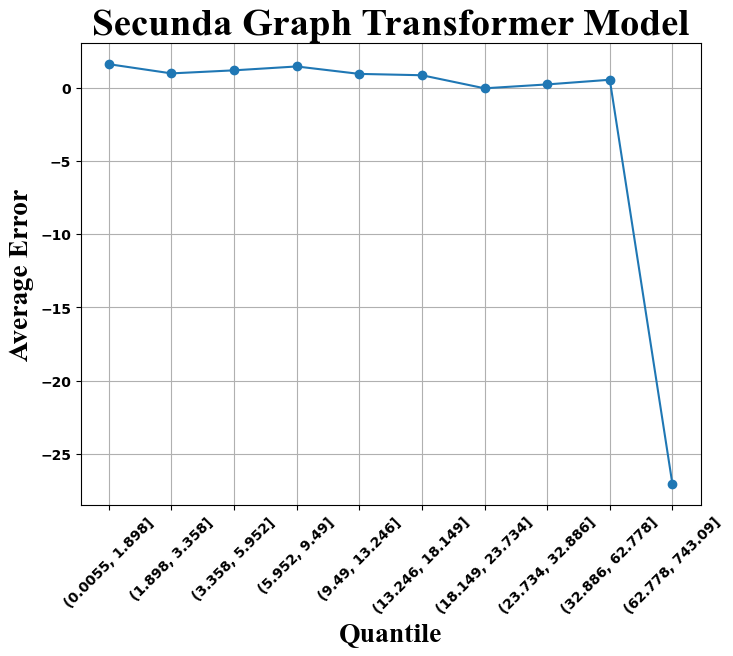

In [20]:
# Plot quantile analysis
# Plot quantiles vs. average errors
rcParams['font.weight'] = 'bold'
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(quantiles.categories) + 1), quantile_errors, marker='o')
plt.xlabel('Quantile', fontname="Times New Roman", size=20,fontweight="bold")
plt.ylabel('Average Error', fontname="Times New Roman", size=20,fontweight="bold")
plt.title('Secunda Graph Transformer Model', fontname="Times New Roman", size=28,fontweight="bold")
plt.xticks(range(1, len(quantiles.categories) + 1), [str(q) for q in quantiles.categories], rotation=45)
plt.grid(True)
plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/Sec2DGraphTransQuan.png", dpi=300, bbox_inches='tight')
plt.show()

# SHAP ANALYSIS FOR 2D MODEL INTERPRETABILITY

Performing SHAP analysis for 2D Graph Transformer interpretability...
Initializing SHAP KernelExplainer for 2D Graph Transformer...


Using 150 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Computing SHAP values...


  0%|          | 0/60 [00:00<?, ?it/s]

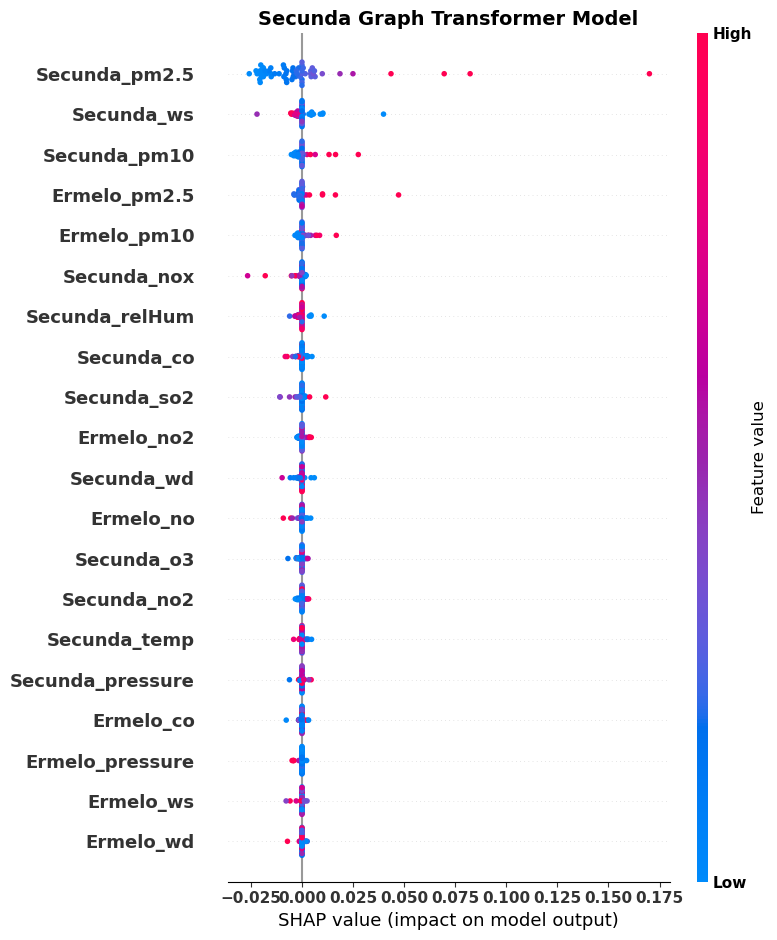

In [ ]:
print("Performing SHAP analysis for 2D Graph Transformer interpretability...")

# Create a wrapper function for SHAP analysis
def graph_transformer_predict_wrapper(X_flat):
    """Wrapper function for Graph Transformer prediction compatible with SHAP."""
    predictions = []
    
    model.eval()
    with torch.no_grad():
        for x_sample in X_flat:
            # Convert to graph data format
            graph_sample = create_2d_graph_sequence_data([x_sample], [0], n_stations, n_feats)[0]
            graph_sample = graph_sample.to(device)
            
            # Create a mini-batch
            loader = DataLoader([graph_sample], batch_size=1, shuffle=False)
            
            for batch in loader:
                pred = model(batch).cpu()
                # Handle scalar predictions properly
                if pred.dim() == 0:
                    # Scalar tensor: use .item()
                    predictions.append(pred.item())
                else:
                    # Array tensor: use first element
                    predictions.append(pred.numpy()[0])
    
    return np.array(predictions)

# Prepare sample data for SHAP
n_shap_samples = min(400, len(test_data))
X_shap = np.array([test_data[i].x.cpu().numpy().flatten() for i in range(n_shap_samples)])
X_background = X_shap[:150]  # Use first 30 samples as background

try:
    print("Initializing SHAP KernelExplainer for 2D Graph Transformer...")
    explainer = shap.KernelExplainer(graph_transformer_predict_wrapper, X_background)
    
    print("Computing SHAP values...")
    shap_values = explainer.shap_values(X_shap[:60], nsamples=100)
    
    # Create feature names for 2D model using actual column names
    # Note: 2D model uses series_to_supervised with n_in=1 (single timestep), no temporal dimension
    feature_names = []
    for station_idx, station in enumerate(stations):
        for feat_name in unique_feature_names:
            feature_names.append(f'{station}_{feat_name}')
    
    # SHAP summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap[:60], feature_names=feature_names, show=False)
    plt.title('Secunda Graph Transformer Model', fontweight='bold', size=14)
    plt.tight_layout()
    plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/Sec2DGraphTransShap2.png", dpi=300, bbox_inches='tight')
    plt.show()
    

    
    print("✅ SHAP analysis completed successfully!")
    
except Exception as e:
    print(f"⚠️ SHAP analysis encountered an error: {e}")
    print("Continuing without SHAP analysis...")

# SAVE RESULTS

In [22]:
print("Saving results...")

# Save predictions
results_df = pd.DataFrame({
    'Actual': targets_unscaled,
    'Predicted': predictions_unscaled,
    'Error': errors
})
results_df.to_csv('2d_graph_transformer_predictions.csv', index=False)

# Save model metrics
metrics_df = pd.DataFrame({
    'Model': ['2D Graph Transformer'],
    'MSE': [mse],
    'RMSE': [rmse],
    'MAE': [mae],
    'R2': [r2],
    'Training_Time': [training_time],
    'Parameters': [total_params],
    'Stations': [n_stations],
    'Features_per_Station': [n_feats]
})
metrics_df.to_csv('2d_graph_transformer_metrics.csv', index=False)

print(f"✅ 2D Graph Transformer completed successfully!")
print(f"📁 Results saved:")
print(f"  📊 Predictions: '2d_graph_transformer_predictions.csv'")
print(f"  📈 Metrics: '2d_graph_transformer_metrics.csv'")  
print(f"  🎯 Best model: '2d_graph_transformer_best_model.pth'")
print(f"  📋 Visualizations: '2d_graph_transformer_results.png', '2d_graph_transformer_quantile_analysis.png'")
if 'shap_values' in locals():
    print(f"  🔍 SHAP analysis: '2d_graph_transformer_shap_summary.png', '2d_graph_transformer_shap_bar.png'")
print(f"  ⏱️ Total time: {time.time() - start_time:.2f} seconds")

Saving results...
✅ 2D Graph Transformer completed successfully!
📁 Results saved:
  📊 Predictions: '2d_graph_transformer_predictions.csv'
  📈 Metrics: '2d_graph_transformer_metrics.csv'
  🎯 Best model: '2d_graph_transformer_best_model.pth'
  📋 Visualizations: '2d_graph_transformer_results.png', '2d_graph_transformer_quantile_analysis.png'
  🔍 SHAP analysis: '2d_graph_transformer_shap_summary.png', '2d_graph_transformer_shap_bar.png'
  ⏱️ Total time: 151006.89 seconds
